In [2]:
import xarray as xr
import cosipy.postprocessing.cosiplot as cosiplot
import pandas as pd


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def compare_mass_balance_mb_sel(
    mb_sel,
    ds,
    variable_name="MB",
    start_year=None,
    end_year=None,
    lat=None,
    lon=None,
    plot=True,
):
    """
    Compare mb_sel winter/summer/annual measurements with COSIPY MB.

    Parameters
    ----------
    mb_sel : pandas.DataFrame or str
        DataFrame or path to CSV containing:
        year, begin_date, end_date, balance, balance_code

    ds : xarray.Dataset
        COSIPY output.

    variable_name : str
        COSIPY mass-balance variable. Default = "MB".

    start_year, end_year : int, optional
        Restrict comparison to these years.

    lat, lon : float, optional
        COSIPY point to use. If None, latitude/longitude from each
        measurement row are used.

    plot : bool
        Make the same two-panel plot as the old function.
    """

    # ---------------------------------------------------------
    # Read data
    # ---------------------------------------------------------
    if isinstance(mb_sel, str):
        df = pd.read_csv(mb_sel)
    else:
        df = mb_sel.copy()

    df["begin_date"] = pd.to_datetime(df["begin_date"])
    df["end_date"] = pd.to_datetime(df["end_date"])

    # Only use the three required balance types
    df = df[
        df["balance_code"].isin(
            ["winter", "summer", "annual"]
        )
    ].copy()

    if start_year is not None:
        df = df[df["year"] >= start_year]

    if end_year is not None:
        df = df[df["year"] <= end_year]

    # ---------------------------------------------------------
    # COSIPY time coverage
    # ---------------------------------------------------------
    model_start = pd.Timestamp(ds.time.min().values)
    model_end = pd.Timestamp(ds.time.max().values)

    print(
        f"COSIPY coverage: "
        f"{model_start} -> {model_end}"
    )

    # ---------------------------------------------------------
    # Sum COSIPY MB over individual measurement period
    # ---------------------------------------------------------
    rows = []

    for _, r in df.iterrows():

        t1 = pd.Timestamp(r["begin_date"])
        t2 = pd.Timestamp(r["end_date"])

        # only periods completely covered by model
        if t1 < model_start or t2 > model_end:
            continue

        # Either explicitly supplied location ...
        if lat is not None and lon is not None:
            target_lat = lat
            target_lon = lon

        # ... or location of measurement
        else:
            target_lat = float(r["latitude"])
            target_lon = float(r["longitude"])

        da = ds[variable_name].sel(
            lat=target_lat,
            lon=target_lon,
            method="nearest",
        )

        sub = da.sel(
            time=slice(t1, t2)
        )

        if sub.time.size == 0:
            continue

        model_balance = float(
            sub.sum().values
        )

        rows.append({
            "year": int(r["year"]),
            "balance_code": r["balance_code"],

            "measured": float(r["balance"]),
            "modeled": model_balance,

            "begin_date": t1,
            "end_date": t2,

            "obs_lat": target_lat,
            "obs_lon": target_lon,

            "model_lat": float(da.lat.values),
            "model_lon": float(da.lon.values),
        })

    result_long = pd.DataFrame(rows)

    if result_long.empty:
        print("No overlapping periods.")
        return None

    # ---------------------------------------------------------
    # Convert to format similar to original function
    # ---------------------------------------------------------

    measured = result_long.pivot_table(
        index="year",
        columns="balance_code",
        values="measured",
        aggfunc="first",
    )

    modeled = result_long.pivot_table(
        index="year",
        columns="balance_code",
        values="modeled",
        aggfunc="first",
    )

    result_df = pd.DataFrame(
        index=sorted(result_long["year"].unique())
    )

    for code, prefix in [
        ("winter", "bw"),
        ("summer", "bs"),
        ("annual", "ba"),
    ]:

        if code in measured:
            result_df[f"{prefix}_fld"] = measured[code]

        if code in modeled:
            result_df[f"{prefix}_model"] = modeled[code]

    result_df.index.name = "year"
    result_df = result_df.reset_index()

    # ---------------------------------------------------------
    # Metrics
    # ---------------------------------------------------------

    def _pair(y, x):
        y = np.asarray(y, dtype=float)
        x = np.asarray(x, dtype=float)

        mask = np.isfinite(y) & np.isfinite(x)

        return y[mask], x[mask]

    def _rmse(y, x):
        y, x = _pair(y, x)

        if len(y) == 0:
            return np.nan

        return float(
            np.sqrt(np.mean((x - y) ** 2))
        )

    def _mae(y, x):
        y, x = _pair(y, x)

        if len(y) == 0:
            return np.nan

        return float(
            np.mean(np.abs(x - y))
        )

    def _corr(y, x):
        y, x = _pair(y, x)

        if len(y) < 2:
            return np.nan

        return float(
            np.corrcoef(y, x)[0, 1]
        )

    def _bias(y, x):
        y, x = _pair(y, x)

        if len(y) == 0:
            return np.nan

        return float(
            np.mean(x - y)
        )

    metrics = {}

    for code, prefix in [
        ("Winter", "bw"),
        ("Summer", "bs"),
        ("Annual", "ba"),
    ]:

        measured_col = f"{prefix}_fld"
        modeled_col = f"{prefix}_model"

        if (
            measured_col not in result_df
            or modeled_col not in result_df
        ):
            continue

        metrics[prefix] = {
            "rmse": _rmse(
                result_df[measured_col],
                result_df[modeled_col],
            ),
            "mae": _mae(
                result_df[measured_col],
                result_df[modeled_col],
            ),
            "corr": _corr(
                result_df[measured_col],
                result_df[modeled_col],
            ),
            "bias": _bias(
                result_df[measured_col],
                result_df[modeled_col],
            ),
        }

        print(f"\n{code}")
        print(
            f"RMSE: "
            f"{metrics[prefix]['rmse']:.3f}"
        )
        print(
            f"MAE:  "
            f"{metrics[prefix]['mae']:.3f}"
        )
        print(
            f"Corr: "
            f"{metrics[prefix]['corr']:.2f}"
        )
        print(
            f"Bias: "
            f"{metrics[prefix]['bias']:.3f}"
        )

    # ---------------------------------------------------------
    # Same plotting style as original
    # ---------------------------------------------------------

    if plot:

        fig, axes = plt.subplots(
            1, 2,
            figsize=(12, 5)
        )

        # =====================================================
        # LEFT: time series
        # =====================================================

        ax = axes[0]

        yrs = result_df["year"]

        if "bw_fld" in result_df:
            ax.plot(
                yrs,
                result_df["bw_fld"],
                "o-",
                label="bw meas",
                color="blue",
            )

        if "bs_fld" in result_df:
            ax.plot(
                yrs,
                result_df["bs_fld"],
                "o-",
                label="bs meas",
                color="red",
            )

        if "ba_fld" in result_df:
            ax.plot(
                yrs,
                result_df["ba_fld"],
                "o-",
                label="ba meas",
                color="green",
            )

        if "bw_model" in result_df:
            ax.plot(
                yrs,
                result_df["bw_model"],
                "o--",
                label="bw model",
                color="blue",
            )

        if "bs_model" in result_df:
            ax.plot(
                yrs,
                result_df["bs_model"],
                "o--",
                label="bs model",
                color="red",
            )

        if "ba_model" in result_df:
            ax.plot(
                yrs,
                result_df["ba_model"],
                "o--",
                label="ba model",
                color="green",
            )

        ax.axhline(
            0,
            color="black",
            linewidth=0.8,
        )

        ax.set_xlabel("Year")
        ax.set_ylabel("MB (m w.e.)")

        ax.set_title(
            "Seasonal and Annual Mass Balance"
        )

        ax.grid(
            True,
            linestyle="--",
            alpha=0.4
        )

        ax.legend(ncol=2)

        # =====================================================
        # RIGHT: measured vs modeled
        # =====================================================

        ax = axes[1]

        scatter_values = []

        for label, prefix, color in [
            ("Winter MB", "bw", "blue"),
            ("Summer MB", "bs", "red"),
            ("Annual MB", "ba", "green"),
        ]:

            obs_col = f"{prefix}_fld"
            mod_col = f"{prefix}_model"

            if (
                obs_col not in result_df
                or mod_col not in result_df
            ):
                continue

            y, x = _pair(
                result_df[obs_col],
                result_df[mod_col],
            )

            if len(y) == 0:
                continue

            ax.scatter(
                y,
                x,
                label=label,
                color=color,
            )

            scatter_values.extend(y)
            scatter_values.extend(x)

        if scatter_values:

            scatter_values = np.asarray(
                scatter_values
            )

            lo, hi = np.nanpercentile(
                scatter_values,
                [1, 99]
            )

            pad = 0.05 * (hi - lo)

            if pad == 0:
                pad = 0.1

            lims = [
                lo - pad,
                hi + pad,
            ]

            ax.plot(
                lims,
                lims,
                "--k"
            )

            ax.set_xlim(lims)
            ax.set_ylim(lims)

        ax.set_xlabel(
            "Measured (m w.e.)"
        )

        ax.set_ylabel(
            "Modeled (m w.e.)"
        )

        ax.set_title(
            "Modeled vs Measured"
        )

        ax.legend(loc="upper left")

        ax.grid(
            True,
            linestyle="--",
            alpha=0.4
        )

        plt.tight_layout()
        plt.show()

    return {
        "df": result_df,
        "long_df": result_long,
        "metrics": metrics,
    }

COSIPY coverage: 2017-05-10 00:00:00 -> 2026-05-15 00:00:00

Winter
RMSE: 0.645
MAE:  0.571
Corr: 0.74
Bias: -0.571

Summer
RMSE: 2.438
MAE:  2.320
Corr: 0.68
Bias: 2.320

Annual
RMSE: 1.970
MAE:  1.825
Corr: 0.86
Bias: 1.825


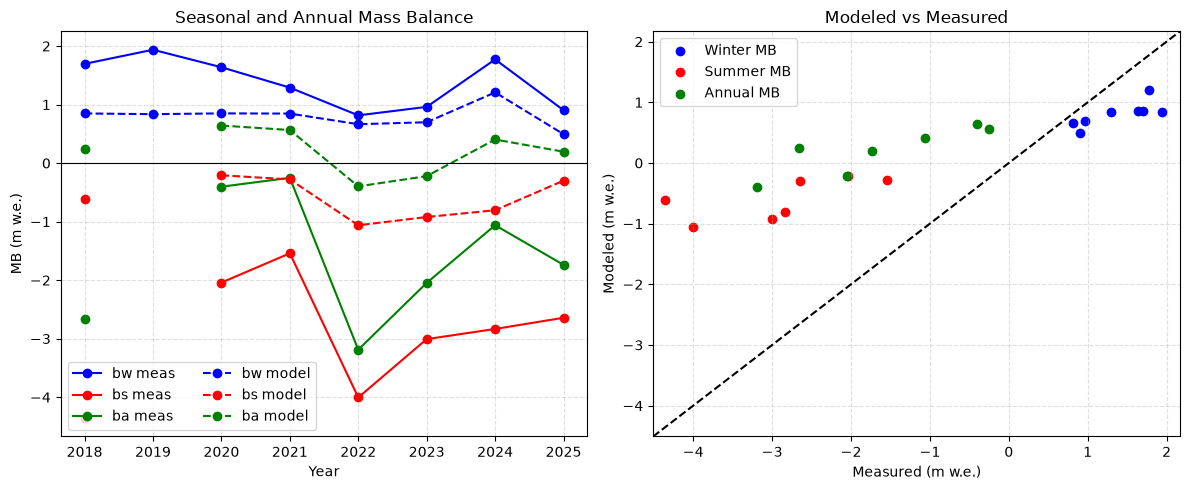

{'df':    year  bw_fld  bw_model  bs_fld  bs_model  ba_fld  ba_model
 0  2018   1.696  0.848860  -4.356 -0.609530  -2.660  0.239333
 1  2019   1.937  0.836080     NaN       NaN     NaN       NaN
 2  2020   1.638  0.849931  -2.041 -0.207697  -0.403  0.642209
 3  2021   1.290  0.846436  -1.541 -0.278247  -0.251  0.565528
 4  2022   0.816  0.664812  -4.004 -1.061907  -3.188 -0.397107
 5  2023   0.961  0.698392  -3.007 -0.920893  -2.046 -0.222501
 6  2024   1.772  1.208464  -2.833 -0.804780  -1.061  0.403650
 7  2025   0.904  0.494352  -2.642 -0.299722  -1.738  0.194631,
 'long_df':     year balance_code  measured   modeled begin_date   end_date    obs_lat  \
 0   2018       annual    -2.660  0.239333 2017-10-01 2018-09-30  46.790320   
 1   2018       winter     1.696  0.848860 2017-10-01 2018-04-30  46.790300   
 2   2018       summer    -4.356 -0.609530 2018-04-30 2018-09-30  46.790320   
 3   2019       winter     1.937  0.836080 2018-10-01 2019-04-30  46.790767   
 4   2020       annu

In [5]:
ds = xr.open_dataset("data/output/HEF_richterteb2test_20170510-20260515.nc")
compare_mass_balance_mb_sel("mb_sel.csv",ds )

COSIPY coverage: 2017-05-10 00:00:00 -> 2026-05-15 00:00:00

Winter
RMSE: 0.581
MAE:  0.506
Corr: 0.76
Bias: -0.506

Summer
RMSE: 2.243
MAE:  2.095
Corr: 0.50
Bias: 2.095

Annual
RMSE: 1.830
MAE:  1.661
Corr: 0.72
Bias: 1.661


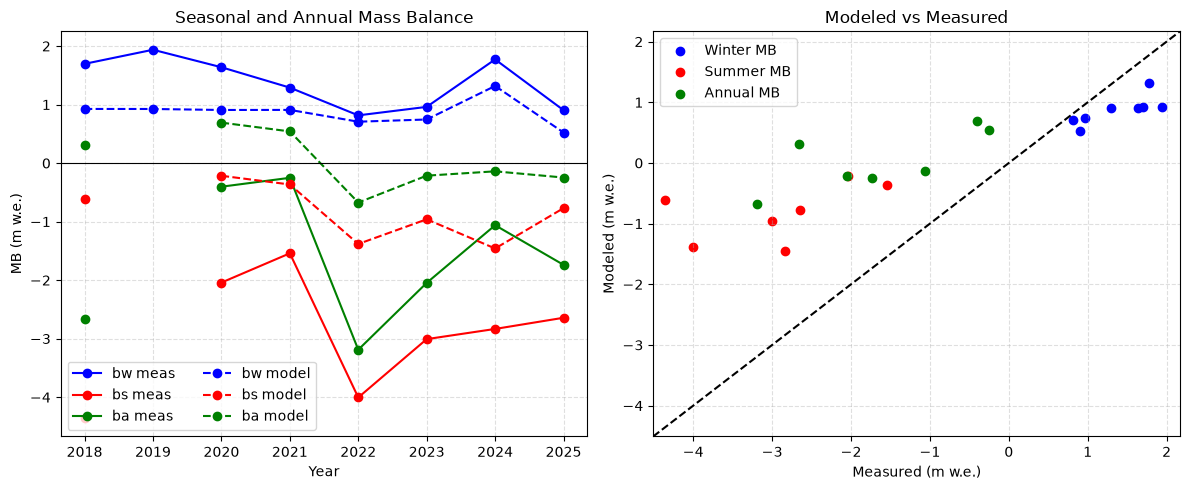

{'df':    year  bw_fld  bw_model  bs_fld  bs_model  ba_fld  ba_model
 0  2018   1.696  0.925707  -4.356 -0.608309  -2.660  0.317396
 1  2019   1.937  0.924970     NaN       NaN     NaN       NaN
 2  2020   1.638  0.907999  -2.041 -0.215996  -0.403  0.691980
 3  2021   1.290  0.909257  -1.541 -0.364980  -0.251  0.541645
 4  2022   0.816  0.707761  -4.004 -1.381359  -3.188 -0.673621
 5  2023   0.961  0.745349  -3.007 -0.959641  -2.046 -0.214292
 6  2024   1.772  1.318268  -2.833 -1.458304  -1.061 -0.140064
 7  2025   0.904  0.522767  -2.642 -0.769037  -1.738 -0.246270,
 'long_df':     year balance_code  measured   modeled begin_date   end_date    obs_lat  \
 0   2018       annual    -2.660  0.317396 2017-10-01 2018-09-30  46.790320   
 1   2018       winter     1.696  0.925707 2017-10-01 2018-04-30  46.790300   
 2   2018       summer    -4.356 -0.608309 2018-04-30 2018-09-30  46.790320   
 3   2019       winter     1.937  0.924970 2018-10-01 2019-04-30  46.790767   
 4   2020       annu

In [8]:
ds = xr.open_dataset("data/output/HEF_6test_20170510-20260515.nc")
compare_mass_balance_mb_sel("mb_sel.csv",ds )

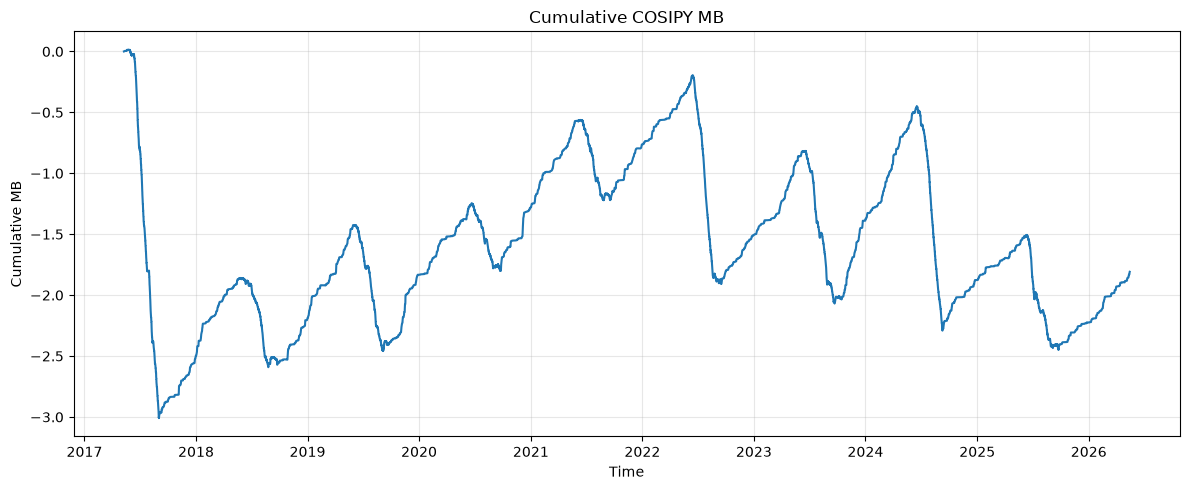

In [10]:
var = "MB"

da = ds[var].isel(lat=0, lon=0).cumsum(dim="time")

plt.figure(figsize=(12, 5))

plt.plot(da["time"], da)

plt.xlabel("Time")
plt.ylabel("Cumulative " + var)
plt.title("Cumulative COSIPY " + var)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [76]:
ds

<xarray.Dataset> Size: 21MB
Dimensions:       (lat: 1, lon: 1, time: 79009)
Coordinates:
  * lat           (lat) float64 8B 46.79
  * lon           (lon) float64 8B 10.74
  * time          (time) datetime64[ns] 632kB 2017-05-10 ... 2026-05-15
Data variables: (12/37)
    HGT           (lat, lon) float64 8B ...
    MASK          (lat, lon) float32 4B ...
    SLOPE         (lat, lon) float32 4B ...
    ASPECT        (lat, lon) float64 8B ...
    T2            (time, lat, lon) float64 632kB ...
    RH2           (time, lat, lon) float64 632kB ...
    ...            ...
    subM          (time, lat, lon) float64 632kB ...
    Q             (time, lat, lon) float64 632kB ...
    REFREEZE      (time, lat, lon) float64 632kB ...
    SNOWHEIGHT    (time, lat, lon) float64 632kB ...
    TOTALHEIGHT   (time, lat, lon) float64 632kB ...
    LAYERS        (time, lat, lon) float64 632kB ...
Attributes: (12/63)
    Start_from_restart_file:                    False
    Stake_evaluation:                           False
    WRF_simulation:                             False
    Compression_level:                          2
    Slurm_use:                                  False
    Full_field:                                 False
    ...                                         ...
    water_density:                              1000.0
    ice_density:                                917.0
    air_density:                                1.1
    sigma:                                      5.67e-08
    zero_temperature:                           273.16
    Surface_emission_coeff:                     0.99

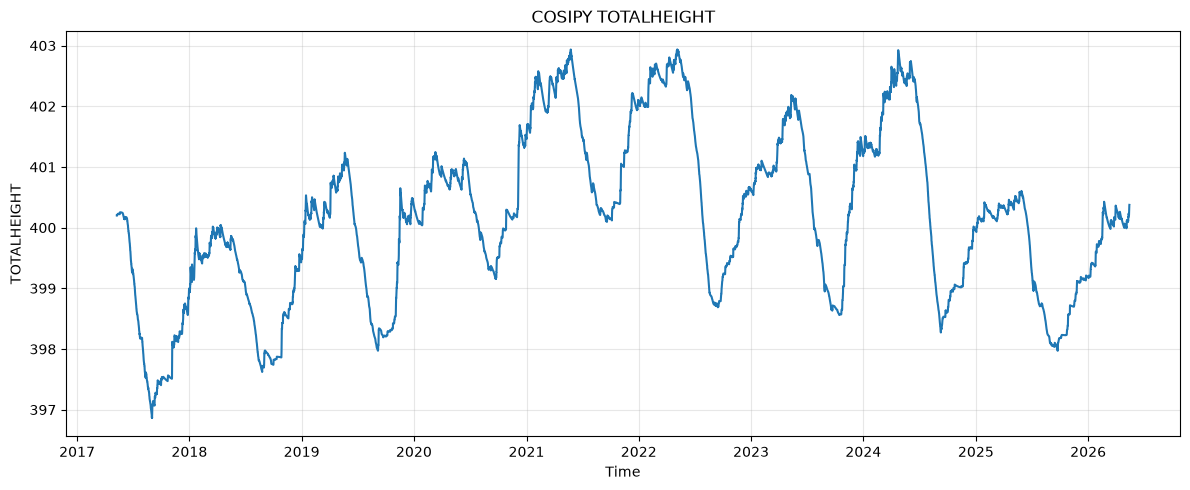

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
var = "TOTALHEIGHT"

ds[var].plot()

plt.xlabel("Time")
plt.ylabel(var)
plt.title("COSIPY " + var)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
fer = pd.read_csv("data/input/HEF/Hintereis_TE_B.csv")

fer = fer.rename(columns={"time": "TIMESTAMP"})

fer.to_csv(
    "data/input/HEF/Hintereis_TE_B_renamed.csv",
    index=False
)

In [ ]:
ds_inp.to_netcdf("data/input/HEF/StatHintereisModelArchive13_26_m.nc", mode="w")

In [72]:
mb = pd.read_csv("mb_sel.csv")
ds_inpold = xr.open_dataset("data/input/HEF/StatHintereisModelArchive13_26.nc")
ds_inp = xr.open_dataset("data/input/HEF/StatHintereisModelArchive13_26_m.nc")
ds_TE = xr.open_dataset("../Hintereis_TE_B.nc")


In [12]:
dem = xr.open_dataset("data/static/HEF_static.nc")
dem

<xarray.Dataset> Size: 647kB
Dimensions:  (lat: 134, lon: 300)
Coordinates:
  * lat      (lat) float64 1kB 46.78 46.78 46.78 46.78 ... 46.82 46.82 46.82
  * lon      (lon) float64 2kB 10.72 10.72 10.72 10.72 ... 10.81 10.81 10.81
Data variables:
    HGT      (lat, lon) float32 161kB ...
    ASPECT   (lat, lon) float32 161kB ...
    SLOPE    (lat, lon) float32 161kB ...
    MASK     (lat, lon) float32 161kB ...

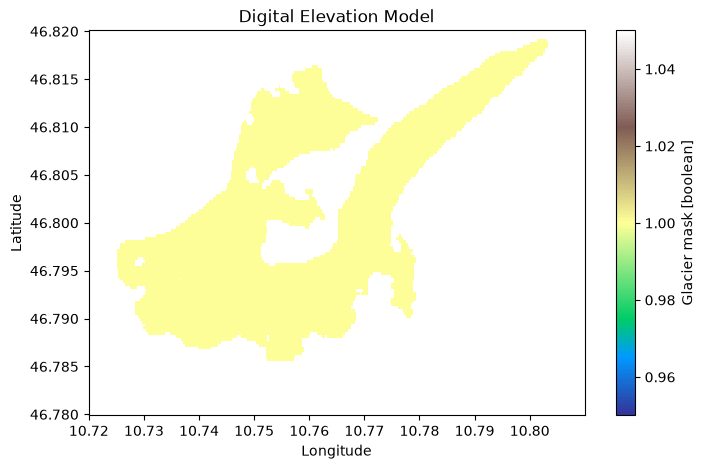

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

dem["MASK"].plot(
    x="lon",
    y="lat",
    cmap="terrain"
)

plt.title("Digital Elevation Model")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [16]:
hef_in = xr.open_dataset("data/input/HEF/HEF_input.nc")
hef_in

<xarray.Dataset> Size: 444kB
Dimensions:  (south_north: 1, west_east: 1, time: 6942)
Coordinates:
    lat      (south_north, west_east) float64 8B ...
    lon      (south_north, west_east) float64 8B ...
  * time     (time) datetime64[ns] 56kB 2018-09-17T08:00:00 ... 2019-07-03T13...
Dimensions without coordinates: south_north, west_east
Data variables:
    HGT      (south_north, west_east) int64 8B ...
    ASPECT   (south_north, west_east) float64 8B ...
    SLOPE    (south_north, west_east) float64 8B ...
    MASK     (south_north, west_east) float64 8B ...
    T2       (time, south_north, west_east) float64 56kB ...
    RH2      (time, south_north, west_east) float64 56kB ...
    U2       (time, south_north, west_east) float64 56kB ...
    G        (time, south_north, west_east) float64 56kB ...
    PRES     (time, south_north, west_east) float64 56kB ...
    RRR      (time, south_north, west_east) float64 56kB ...
    LWin     (time, south_north, west_east) float64 56kB ...

In [18]:
import pandas as pd

df = pd.read_csv(
    "./data/input/HEF/StatHintereisModelArchive2_cleaned.csv",
    parse_dates=["TIMESTAMP"]
)

df = df.set_index("TIMESTAMP").sort_index()

d = df.loc["2016-01-01":"2019-12-31"]

print("Rows in 2016:", len(d))
print("First timestamp:", d.index.min())
print("Last timestamp:", d.index.max())
print("Duplicates:", d.index.duplicated().sum())

gaps = d.index.to_series().diff()

print("Largest gap:", gaps.max())
print("\nLargest gaps:")
print(gaps.sort_values(ascending=False).head(20))

Rows in 2016: 31416
First timestamp: 2016-06-01 00:00:00
Last timestamp: 2019-12-31 23:00:00
Duplicates: 0
Largest gap: 0 days 01:00:00

Largest gaps:
TIMESTAMP
2016-06-01 01:00:00   0 days 01:00:00
2018-10-22 02:00:00   0 days 01:00:00
2018-10-22 00:00:00   0 days 01:00:00
2018-10-21 23:00:00   0 days 01:00:00
2018-10-21 22:00:00   0 days 01:00:00
2018-10-21 21:00:00   0 days 01:00:00
2018-10-21 20:00:00   0 days 01:00:00
2018-10-21 19:00:00   0 days 01:00:00
2018-10-21 18:00:00   0 days 01:00:00
2018-10-21 17:00:00   0 days 01:00:00
2018-10-21 16:00:00   0 days 01:00:00
2018-10-21 15:00:00   0 days 01:00:00
2018-10-21 14:00:00   0 days 01:00:00
2018-10-21 13:00:00   0 days 01:00:00
2018-10-21 12:00:00   0 days 01:00:00
2018-10-21 11:00:00   0 days 01:00:00
2018-10-21 10:00:00   0 days 01:00:00
2018-10-21 09:00:00   0 days 01:00:00
2018-10-21 08:00:00   0 days 01:00:00
2018-10-21 07:00:00   0 days 01:00:00
Name: TIMESTAMP, dtype: timedelta64[ns]


In [1]:
import numpy as np
import pandas as pd

input_file = "./data/input/HEF/Hintereis_TE_B_renamed.csv"
output_file = "./data/input/HEF/Hintereis_TE_B_prepared.csv"

# IMPORTANT: set this to the same altitude used as stationAlt in your utilities_config.toml
station_altitude = 2976.0  # m


df = pd.read_csv(input_file)


# ============================================================
# Relative humidity from T2 and Td2
# T2 and Td2 are in Kelvin
# ============================================================

T_c = df["T2"] - 273.15
Td_c = df["Td2"] - 273.15

df["RH_dewpoint"] = 100 * (
    np.exp((17.625 * Td_c) / (243.04 + Td_c))
    / np.exp((17.625 * T_c) / (243.04 + T_c))
)

df["RH_dewpoint"] = df["RH_dewpoint"].clip(0, 100)


# ============================================================
# Pressure from mean sea-level pressure to station altitude
# PRES must currently be MSLP in hPa
# ============================================================

df["PRES_alt"] = (
    df["PRES"]
    * (1 - 0.0065 * station_altitude / 288.15) ** 5.255
)


# ============================================================
# Check result
# ============================================================

print(
    df[
        ["TIMESTAMP", "T2", "Td2",
         "RH_dewpoint", "PRES", "PRES_alt"]
    ].head()
)


# ============================================================
# Save
# ============================================================

df.to_csv(output_file, index=False)

print("Saved:", output_file)

             TIMESTAMP          T2         Td2  RH_dewpoint         PRES  \
0  2013-02-11 01:00:00  253.651138  251.673660    84.279952  1012.566250   
1  2013-02-11 02:00:00  254.118057  252.107254    84.096359  1011.694375   
2  2013-02-11 03:00:00  254.488541  252.603561    85.066322  1010.795000   
3  2013-02-11 04:00:00  254.964172  253.031479    84.775414  1009.828750   
4  2013-02-11 05:00:00  255.004166  253.139664    85.279894  1008.968750   

     PRES_alt  
0  702.796039  
1  702.190893  
2  701.566660  
3  700.896011  
4  700.299107  
Saved: ./data/input/HEF/Hintereis_TE_B_prepared.csv


In [ ]:
df_restart = xr.open_dataset("cosipy/data/restart/restart_2009-01-10T00-00.nc")
df_restart

<xarray.Dataset> Size: 10kB
Dimensions:           (lat: 1, lon: 1, layer: 200)
Coordinates:
  * lat               (lat) float64 8B 30.47
  * lon               (lon) float64 8B 90.64
  * layer             (layer) int64 2kB 0 1 2 3 4 5 ... 194 195 196 197 198 199
    time              datetime64[ns] 8B ...
Data variables:
    NLAYERS           (lat, lon) float64 8B ...
    NEWSNOWHEIGHT     (lat, lon) float64 8B ...
    NEWSNOWTIMESTAMP  (lat, lon) float64 8B ...
    OLDSNOWTIMESTAMP  (lat, lon) float64 8B ...
    LAYER_HEIGHT      (lat, lon, layer) float64 2kB ...
    LAYER_RHO         (lat, lon, layer) float64 2kB ...
    LAYER_T           (lat, lon, layer) float64 2kB ...
    LAYER_LWC         (lat, lon, layer) float64 2kB ...
    LAYER_IF          (lat, lon, layer) float64 2kB ...

In [4]:
df_out = xr.open_dataset("data/output/Zhadang_ERA5_20090110-20090510.nc")
df_out

<xarray.Dataset> Size: 783kB
Dimensions:       (lat: 1, lon: 1, time: 2880)
Coordinates:
  * lat           (lat) float64 8B 30.47
  * lon           (lon) float64 8B 90.64
  * time          (time) datetime64[ns] 23kB 2009-01-10T01:00:00 ... 2009-05-10
Data variables: (12/37)
    HGT           (lat, lon) float64 8B ...
    MASK          (lat, lon) float32 4B ...
    SLOPE         (lat, lon) float32 4B ...
    ASPECT        (lat, lon) float32 4B ...
    T2            (time, lat, lon) float64 23kB ...
    RH2           (time, lat, lon) float64 23kB ...
    ...            ...
    subM          (time, lat, lon) float64 23kB ...
    Q             (time, lat, lon) float64 23kB ...
    REFREEZE      (time, lat, lon) float64 23kB ...
    SNOWHEIGHT    (time, lat, lon) float64 23kB ...
    TOTALHEIGHT   (time, lat, lon) float64 23kB ...
    LAYERS        (time, lat, lon) float64 23kB ...
Attributes: (12/63)
    Start_from_restart_file:                    True
    Stake_evaluation:                           False
    WRF_simulation:                             False
    Compression_level:                          2
    Slurm_use:                                  False
    Full_field:                                 False
    ...                                         ...
    water_density:                              1000.0
    ice_density:                                917.0
    air_density:                                1.1
    sigma:                                      5.67e-08
    zero_temperature:                           273.16
    Surface_emission_coeff:                     0.99

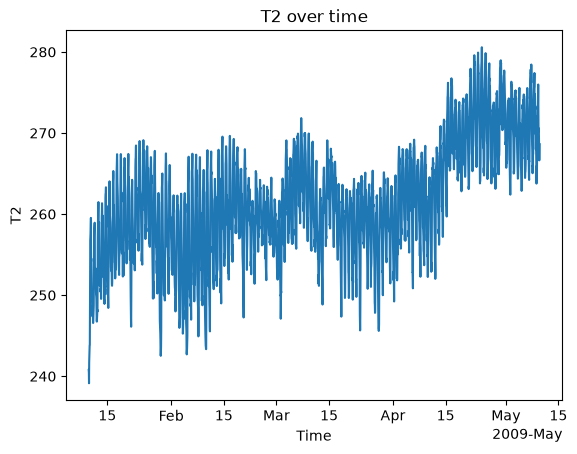

In [8]:
import matplotlib.pyplot as plt

df_out["T2"].isel(lat=0, lon=0).plot()

plt.title("T2 over time")
plt.xlabel("Time")
plt.ylabel("T2")
plt.show()